# Análise Fatorial: Identificando Pilares de Satisfação no RH 🚀

Este projeto utiliza **Análise Fatorial Exploratória (AFE)** para reduzir a dimensionalidade de uma pesquisa de clima organizacional, transformando 6 variáveis isoladas em fatores estratégicos que explicam o comportamento dos colaboradores.

## 📌 Contexto do Problema
O RH de uma empresa coletou dados de 500 colaboradores sobre:
* **Salário (R$)**: Remuneração bruta.
* **Satisfação com Benefícios**: Nota de 1 a 10.
* **Relação com Gestor**: Nota de 1 a 10.
* **Feedback**: Nota de 1 a 10.
* **Work-Life Balance (WLB)**: Nota de 1 a 10.
* **Flexibilidade**: Nota de 1 a 10.

O desafio é entender se essas métricas se agrupam em "conceitos latentes" (fatores) que não podem ser medidos diretamente.

In [1]:
# Imports 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import factor_analyzer
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Douglas Vittori" 

Author: Douglas Vittori



In [3]:
# Semente para resultados reproduzíveis
np.random.seed(42)
n_rows = 500 # Aumentei para 100 para dar mais corpo ao seu portfólio

# 1. Gerando Salário entre 2k e 10k
salario = np.random.uniform(2000, 10000, n_rows)

# 2. Gerando as outras variáveis (Notas de 1 a 10)
# Criando correlação: quem ganha mais tende a estar mais satisfeito com benefícios
beneficios = (salario / 1000) + np.random.normal(0, 1, n_rows)

# Variáveis de Gestão (independentes do salário no nosso simulador)
relacao_gestor = np.random.uniform(3, 10, n_rows)
feedback = relacao_gestor * 0.8 + np.random.normal(0, 0.5, n_rows)

# Variáveis de Qualidade de Vida (podem ser menores para salários muito altos - "custo do cargo")
work_life_balance = 12 - (salario / 1000) + np.random.normal(0, 1, n_rows)
flexibilidade = work_life_balance * 0.9 + np.random.normal(0, 0.5, n_rows)

# Criando o DataFrame
df = pd.DataFrame({
    'Salario_RS': salario,
    'Satisfacao_Beneficios': beneficios,
    'Relacao_Gestor': relacao_gestor,
    'Feedback': feedback,
    'Work_Life_Balance': work_life_balance,
    'Flexibilidade': flexibilidade
})

# Ajustando as notas para o limite de 1 a 10 e arredondando
cols_notas = ['Satisfacao_Beneficios', 'Relacao_Gestor', 'Feedback', 'Work_Life_Balance', 'Flexibilidade']
df[cols_notas] = df[cols_notas].clip(1, 10).round(1)
df['Salario_RS'] = df['Salario_RS'].round(2)

# Salvando
df.to_csv('projeto_rh_fatorial.csv', index=False)
print("Dataset 'projeto_rh_fatorial.csv' gerado!")

Dataset 'projeto_rh_fatorial.csv' gerado!


In [4]:
df.shape

(500, 6)

In [5]:
df.sample(10)

,Salario_RS,Satisfacao_Beneficios,Relacao_Gestor,Feedback,Work_Life_Balance,Flexibilidade
8,6808.92,8.0,7.9,5.4,4.9,4.8
224,4121.62,4.8,4.3,3.0,7.1,6.2
70,8177.96,8.1,7.9,5.6,4.8,4.7
474,6221.61,6.4,6.9,5.2,4.3,3.7
404,4560.40,5.0,3.3,2.2,7.3,6.4
310,5511.77,5.8,3.2,2.2,6.0,5.0
425,6396.23,6.0,6.2,5.5,4.3,4.4
363,6364.93,5.0,6.7,6.1,5.7,5.0
167,3492.15,3.7,9.3,7.1,8.1,7.5
192,9203.34,7.7,4.4,4.1,3.4,3.6


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Salario_RS             500 non-null    float64
 1   Satisfacao_Beneficios  500 non-null    float64
 2   Relacao_Gestor         500 non-null    float64
 3   Feedback               500 non-null    float64
 4   Work_Life_Balance      500 non-null    float64
 5   Flexibilidade          500 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB


## Análise Exploratória e Limpeza de Dados

In [7]:
# Verificando valores nulos
print(df.isnull().sum())

Salario_RS               0
Satisfacao_Beneficios    0
Relacao_Gestor           0
Feedback                 0
Work_Life_Balance        0
Flexibilidade            0
dtype: int64


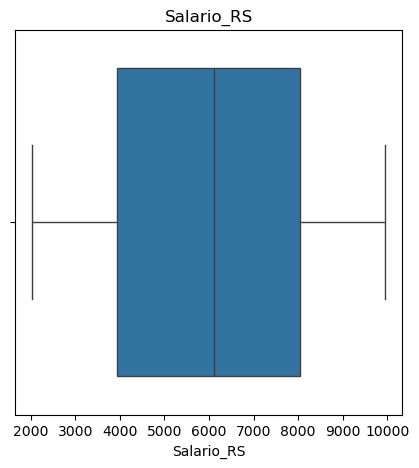

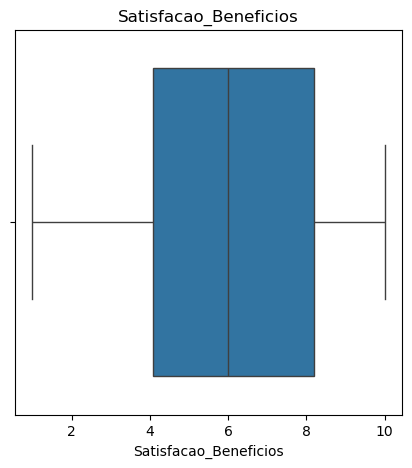

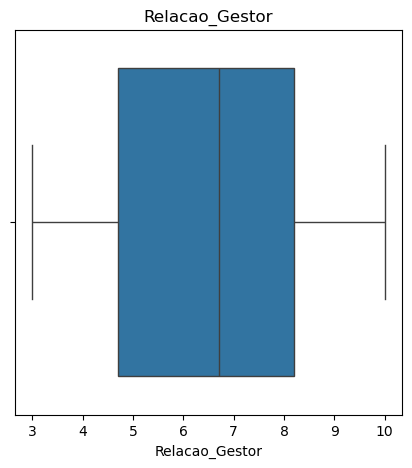

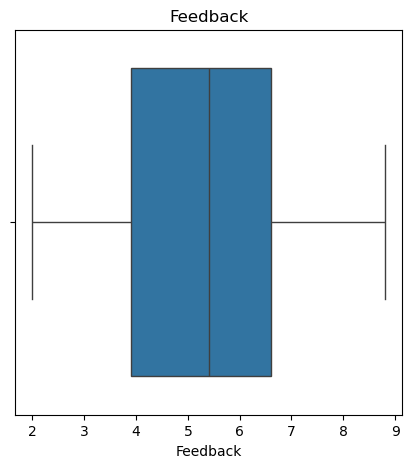

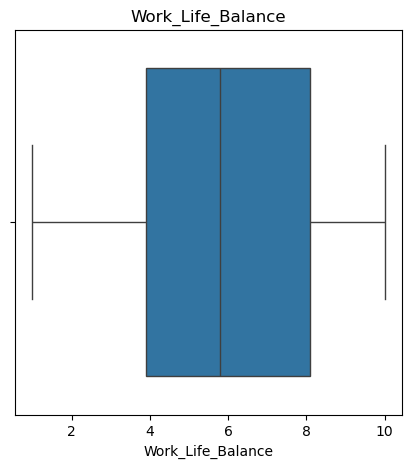

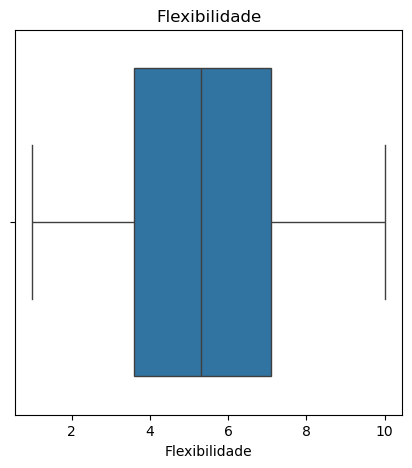

In [8]:
# Visualizando outliers para cada variável no DataFrame
for column in df.columns:
    if df[column].dtype in ['float64']:  
        plt.figure(figsize = (5, 5))
        sns.boxplot(x = df[column])
        plt.title(column)
        plt.show()

In [9]:
df.describe()

,Salario_RS,Satisfacao_Beneficios,Relacao_Gestor,Feedback,Work_Life_Balance,Flexibilidade
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5988.493700,5.958200,6.549600,5.282400,5.944600,5.416000
std,2389.507202,2.554981,2.034014,1.689497,2.513274,2.318434
min,2040.490000,1.000000,3.000000,2.000000,1.000000,1.000000
25%,3930.240000,4.075000,4.700000,3.900000,3.900000,3.600000
50%,6105.310000,6.000000,6.700000,5.400000,5.800000,5.300000
75%,8049.000000,8.200000,8.200000,6.600000,8.100000,7.100000
max,9943.720000,10.000000,10.000000,8.800000,10.000000,10.000000


In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Salario_RS               4118.760
Satisfacao_Beneficios       4.125
Relacao_Gestor              3.500
Feedback                    2.700
Work_Life_Balance           4.200
Flexibilidade               3.500
dtype: float64


In [11]:
# Vamos checar os valores que estão 1.5 acima ou abaixo do IQR. Esses valores são considerados outliers.
outliers = ((df < (Q1 - 2.5 * IQR)) | (df > (Q3 + 2.5 * IQR))).any(axis = 1)

In [12]:
# Filtramos os outliers
df_outliers = df[outliers]

In [13]:
# Visualizamos os outliers
df_outliers

,Salario_RS,Satisfacao_Beneficios,Relacao_Gestor,Feedback,Work_Life_Balance,Flexibilidade


In [14]:
# Calculando a matriz de correlação
correlation_matrix = df.corr()

In [15]:
correlation_matrix

,Salario_RS,Satisfacao_Beneficios,Relacao_Gestor,Feedback,Work_Life_Balance,Flexibilidade
Salario_RS,1.000000,0.931146,0.044865,0.053183,-0.930943,-0.913331
Satisfacao_Beneficios,0.931146,1.000000,0.039432,0.057243,-0.873246,-0.859730
Relacao_Gestor,0.044865,0.039432,1.000000,0.955518,-0.050780,-0.036885
Feedback,0.053183,0.057243,0.955518,1.000000,-0.058493,-0.046531
Work_Life_Balance,-0.930943,-0.873246,-0.050780,-0.058493,1.000000,0.976803
Flexibilidade,-0.913331,-0.859730,-0.036885,-0.046531,0.976803,1.000000


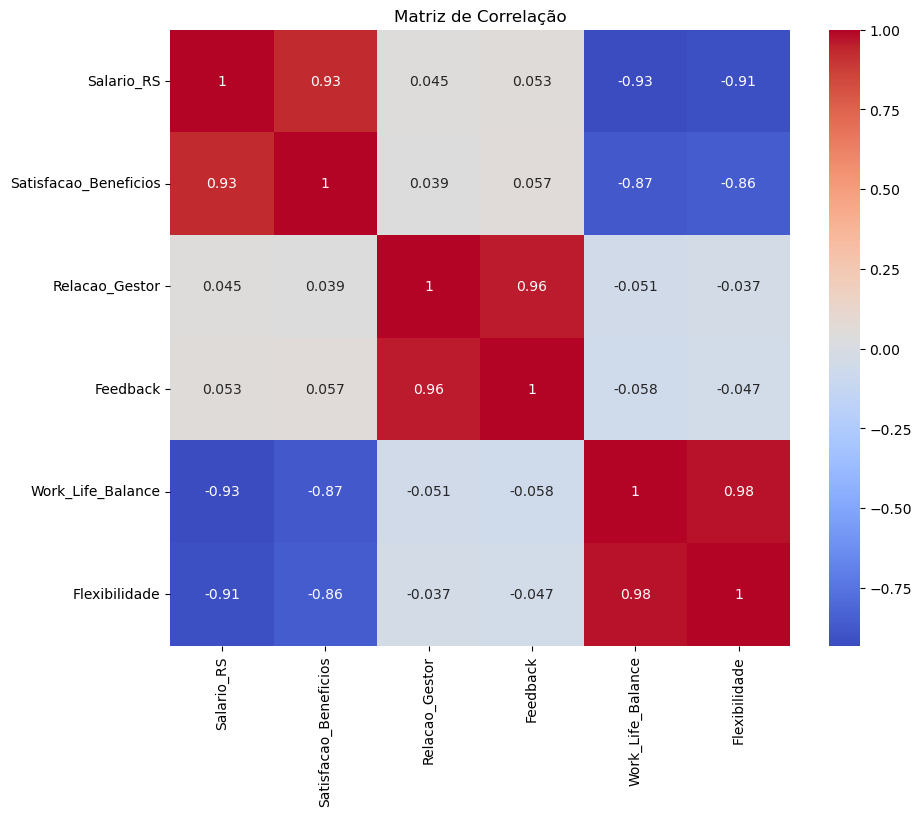

In [16]:
# Plot
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Matriz de Correlação')
plt.show()

## 🛠️ Tratamento e Preparação de Dados

### 2. Desafio das Escalas
Identifiquei que a variável **Salário** (escala de 2.000 a 10.000) possuía uma variância muito superior às notas (escala de 1 a 10). Para evitar que o algoritmo priorizasse apenas o salário, apliquei a padronização **Z-Score** utilizando `StandardScaler`.

* A padronização é necessária para que a variância do Salário (escala em milhares) não domine a extração de fatores sobre as Notas (escala de 1 a 10).

In [17]:
from sklearn.preprocessing import StandardScaler 

# Cria o padronizador
scaler = StandardScaler()

In [18]:
# Padronizando as Variáveis 

df_scaled = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)

In [19]:
df_scaled.head()

,Salario_RS,Satisfacao_Beneficios,Relacao_Gestor,Feedback,Work_Life_Balance,Flexibilidade
0,-0.415637,-0.257872,-0.811819,-0.759803,0.261037,0.381674
1,1.515308,1.583514,1.304344,1.136149,-1.690564,-1.561236
2,0.782306,1.113373,1.009065,0.958404,-1.292279,-1.647587
3,0.335458,0.094733,0.516934,0.425167,-0.336392,-0.481842
4,-1.147972,-1.433225,1.205918,1.313895,0.500008,0.727080


## 2. Validação Estatística
Antes de rodar o modelo, validei se os dados eram "fatoráveis":
* **KMO (Kaiser-Meyer-Olkin):** Verifiquei se o valor era > 0.6.
* **Teste de Bartlett:** Confirmei a significância (p-valor < 0.05).

### Verificando a Adequação dos Dados com o Teste de Bartlett

In [20]:
# Verificando a adequação dos dados
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)

In [21]:
print('Estatística do Teste:', chi_square_value, '\nValor-p:', p_value)

Estatística do Teste: 4753.157972947694 
Valor-p: 0.0


### Verificando a Adequação dos Dados com o Teste de Kaiser-Meyer-Olkin (KMO)

In [22]:
# Verificando a adequação dos dados usando o teste de Kaiser-Meyer-Olkin (KMO)
kmo_all, kmo_model = calculate_kmo(df_scaled)

In [23]:
print('KMO Global:', kmo_model)

KMO Global: 0.7284369290517791


In [24]:
print('KMO Por Variável:', kmo_all)

KMO Por Variável: [0.82094108 0.83781402 0.49832907 0.49978616 0.75506894 0.77661694]


## 📊 Resultados e Descobertas

### Definição do Número de Fatores

In [25]:
# Cria o analisador
fa = FactorAnalyzer(rotation = "varimax")

In [26]:
# Treina o analisador
fa.fit(df_scaled)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

> Baseado no gráfico de cotovelo, podemos escolher o número de fatores onde o valor começa a se estabilizar.

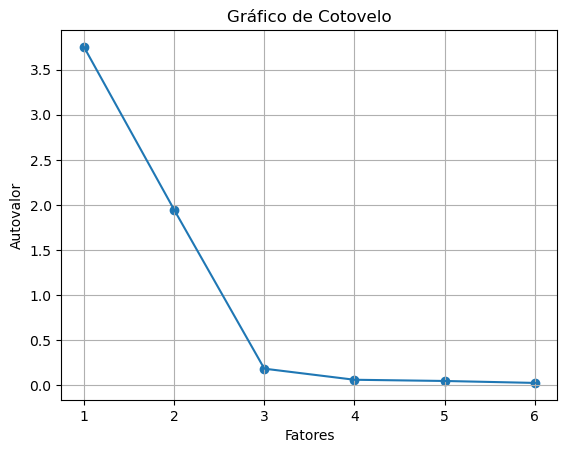

In [27]:
# Verificando os autovalores
eigen_values, vectors = fa.get_eigenvalues()
plt.scatter(range(1, df_scaled.shape[1]+1), eigen_values)
plt.plot(range(1, df_scaled.shape[1]+1), eigen_values)
plt.title('Gráfico de Cotovelo')
plt.xlabel('Fatores')
plt.ylabel('Autovalor')
plt.grid()
plt.show()

In [28]:
# Realizando análise fatorial com 3 fatores 
fa = FactorAnalyzer(n_factors = 3, rotation = "varimax")
fa.fit(df_scaled)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [29]:
# Verificando a carga fatorial
loadings = fa.loadings_
print(loadings)

[[-0.95389262  0.04711734  0.12222054]
 [-0.92693584  0.04609217  0.36571053]
 [ 0.00222208  0.97879756 -0.00749162]
 [-0.00804567  0.97631594  0.01065197]
 [ 0.98863262 -0.05314409  0.12394972]
 [ 0.97100816 -0.03996058  0.11604843]]


In [30]:
# Comunalidades 
fa.get_communalities()

array([0.92706903, 0.99507873, 0.95810572, 0.95337101, 0.99558229,
       0.95792094])

### 📉 Refinamento do Modelo: Decidindo o Número de Fatores

Após a análise inicial dos Autovalores (Eigenvalues) e a inspeção visual do Scree Plot, observei que, embora o critério estatístico sugerisse a possibilidade de 3 fatores, a interpretação prática da solução com 3 dimensões apresentou-se excessivamente fragmentada.

O terceiro fator apresentou cargas fatoriais baixas (abaixo de 0.4) para a maioria das variáveis, não conseguindo isolar um conceito de negócio claro. Em análise de dados, priorizamos a parcimônia: o modelo mais simples que explica bem os dados é sempre superior.

Portanto, tomei a decisão técnica de consolidar a análise em 2 fatores principais. Esta escolha visa:

* Aumentar a interpretabilidade dos pilares para os tomadores de decisão (RH).

* Garantir a estabilidade das cargas fatoriais, evitando fatores com apenas uma variável dominante.

* Focar na variância relevante, que separa claramente os eixos de "Compensação/Vida Pessoal" e "Liderança".

Abaixo, executo o modelo final com n_factors=2 e rotação Varimax para obter a estrutura de dados mais limpa.

In [31]:
# Realizando análise fatorial com 2 fatores 
fa = FactorAnalyzer(n_factors = 2, rotation = "varimax")
fa.fit(df_scaled)

FactorAnalyzer(n_factors=2, rotation='varimax', rotation_kwargs={})

In [32]:
# Verificando a carga fatorial
loadings = fa.loadings_
print(loadings)

[[ 0.97052428 -0.05447945]
 [ 0.91452276 -0.0491844 ]
 [ 0.09953164  0.9724252 ]
 [ 0.11074057  0.97128022]
 [-0.97539027  0.04946389]
 [-0.95855488  0.06069541]]


In [33]:
# Comunalidades 
fa.get_communalities()

array([0.94488539, 0.83877098, 0.95551732, 0.95564875, 0.95383286,
       0.92251139])

In [34]:
df_scaled.columns

Index(['Salario_RS', 'Satisfacao_Beneficios', 'Relacao_Gestor', 'Feedback',
       'Work_Life_Balance', 'Flexibilidade'],
      dtype='object')

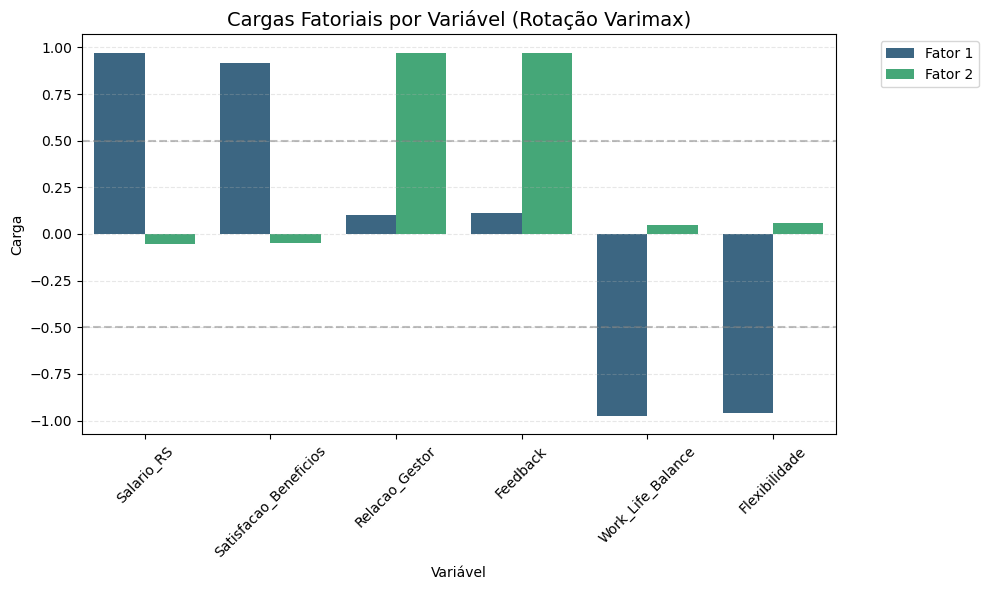

In [35]:
# 1. Transformando a matriz em DataFrame
# Use os nomes das colunas originais do seu DF para o índice
loadings_df = pd.DataFrame(fa.loadings_, 
                           columns=['Fator 1', 'Fator 2'], 
                           index=df.columns)

# 2. Agora sim, usamos o reset_index() no DataFrame para o Seaborn entender as categorias
plt.figure(figsize=(10, 6))
loadings_plot = loadings_df.reset_index().melt(id_vars='index')
loadings_plot.columns = ['Variável', 'Fator', 'Carga']

# 3. Plotagem
sns.barplot(data=loadings_plot, x='Variável', y='Carga', hue='Fator', palette='viridis')

# Linhas de referência para facilitar a leitura das cargas fortes
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=-0.5, color='gray', linestyle='--', alpha=0.5)

plt.title('Cargas Fatoriais por Variável (Rotação Varimax)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

### 📊 Interpretação dos Fatores (Cargas Fatoriais)

Após a rotação Varimax, os dados se agruparam em dois eixos estratégicos:

1. **Fator 1 - Pilar de Compensação Inversa:** Revelou um *trade-off* crítico. Variáveis financeiras (Salário e Benefícios) possuem cargas positivas altas, enquanto variáveis de bem-estar (WLB e Flexibilidade) possuem cargas negativas altas. Isso indica que, nesta organização, cargos de maior remuneração exigem uma renúncia direta da flexibilidade pessoal.

2. **Fator 2 - Pilar de Liderança Direta:** Agrupou exclusivamente as variáveis de 'Relação com Gestor' e 'Feedback'. Este fator é independente do Fator 1, sugerindo que a percepção de uma boa liderança é resiliente e não está atrelada ao nível salarial do colaborador.

**Ação sugerida para o RH:** Focar em programas de flexibilidade para cargos de alta senioridade (Fator 1) e investir em treinamentos de liderança como uma estratégia de retenção de baixo custo financeiro (Fator 2).

In [36]:
%reload_ext watermark
%watermark -a "Douglas Vittori"

Author: Douglas Vittori



In [37]:
#%watermark -v -m

In [38]:
#%watermark --iversions

# Fim